In [1]:
import numpy as np
from matplotlib import pyplot as plt
from time import time
import PT_model
from PT_model import Acoustic_2D_Cartesian_Grid
import PT_data_classes
from copy import copy
import PT_data 
import PT_routines

1750.0 1750.0


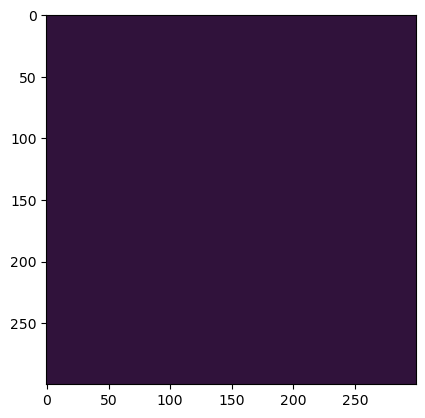

In [2]:
model = PT_model.load_model("Model_Init")

vmin = 1500.0
vmax = 2000.0

print(model.model_params.c.min(), model.model_params.c.max())
plt.imshow(model.model_params.c, cmap="turbo")

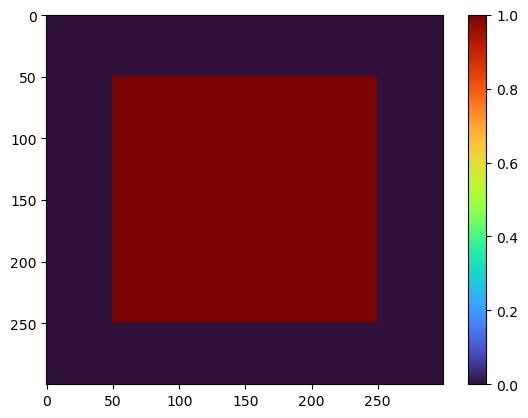

In [3]:
# create a preconditioner 

sigmoid = lambda x, x0, alpha: 1 / (1 + np.exp(-alpha*(x-x0)))

P = np.ones((model.model_params.Nz, model.model_params.Nx))
P[0:50, :] = 0.0
P[250:, :] = 0.0
P[:, 0:50] = 0.0
P[:, 250:] = 0.0


plt.imshow(P, cmap="turbo", aspect='auto')
plt.colorbar()


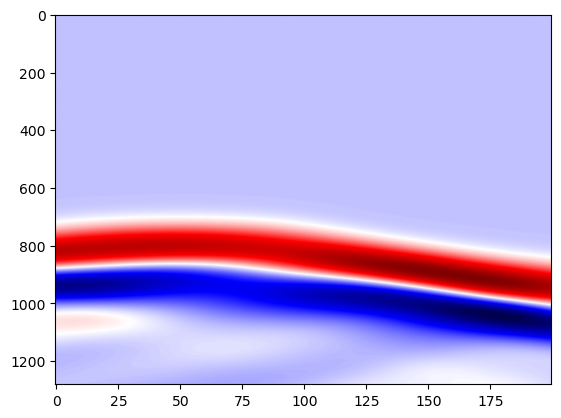

In [4]:
# load marmousi data

obs_data_set = PT_data.load_data_set("Box_Data")

SG_plt = obs_data_set.shot_gathers[1].gather
plt.imshow(SG_plt, aspect="auto", cmap="seismic")

# create save indice
save_inds = np.arange(0, obs_data_set.shot_gathers[0].aquisition_params.Nt+1).tolist()
save_inds = save_inds[::10]

In [5]:
# set preprocessing and adjiont parameters

preprocess_params = PT_data_classes.Preprocess_params(mute=False, 
                                                         filter=None,
                                                         filter_bounds=[15.0],
                                                         normalize=False)

adjoint_params = PT_data_classes.Adjoint_params(adjoint_source="L2", additonal_parmas=[])


In [6]:
Ns = len(obs_data_set.shot_gathers)

model_list = []
aquisition_params_list = []
preprocess_params_list = []
adjoint_params_list = []
save_inds_list = []
SG_OBS_list = []

for i in range(Ns): 
    model_list.append(model)
    aquisition_params_list.append(obs_data_set.shot_gathers[i].aquisition_params)
    preprocess_params_list.append(preprocess_params)
    adjoint_params_list.append(adjoint_params)
    save_inds_list.append(save_inds)
    SG_OBS_list.append(obs_data_set.shot_gathers[i])

In [7]:

# set the number of iterations
N_iters = 50

# initialize misfit history
misfits = []

# set maximum update
max_update = 50.0

for iter in range(N_iters):

	print("Starting Iteration ", iter)

	# compute the Kernels
	
	OUT = PT_routines.Compute_Kernel_Parallel(model_list=model_list,
											aquisition_params_list=aquisition_params_list,
											preprocess_params_lsit=preprocess_params_list,
											adjoint_params_list=adjoint_params_list,
											save_inds_list=save_inds_list,
											SG_OBS_list=SG_OBS_list)

	# initialize the gradient
	grad = np.zeros((model.model_params.Nz, model.model_params.Nx), dtype=np.float32, order='C')
	P1 = np.zeros((model.model_params.Nz, model.model_params.Nx), dtype=np.float32, order='C')

	# initialize reisual
	resid = 0.0

	# parse outputs
	for i in range(len(OUT)):
		SK, HK = OUT[i][0:2]
		grad += SK
		P1 += HK
		resid += np.sum(OUT[i][3])

	# precondition the gradient
	h = grad*P/P1
		
	alpha = max_update / np.max(np.abs(h))

	# update model
	model.model_params.c -= alpha * h	
	model.model_params.c = np.clip(model.model_params.c, vmin, vmax)

	# update misfit history
	misfits.append(resid)

	print("Misfit: ", misfits[-1]/misfits[0])
	# implement stopping criteria
	if iter > 1:
		if misfits[-1] > misfits[-2]:
			break



Starting Iteration  0
Misfit:  1.0
Starting Iteration  1
Misfit:  0.8852880429711393
Starting Iteration  2
Misfit:  0.7811239902988889
Starting Iteration  3
Misfit:  0.6866424148837744
Starting Iteration  4
Misfit:  0.6009266259914522
Starting Iteration  5
Misfit:  0.5228018835018025
Starting Iteration  6
Misfit:  0.4580315246525454
Starting Iteration  7
Misfit:  0.40565782810678014
Starting Iteration  8
Misfit:  0.3572978480441443
Starting Iteration  9
Misfit:  0.31144864022866964
Starting Iteration  10
Misfit:  0.26821037775868245
Starting Iteration  11
Misfit:  0.22823549247433014
Starting Iteration  12
Misfit:  0.19226184797716417
Starting Iteration  13
Misfit:  0.1606252340584609
Starting Iteration  14
Misfit:  0.13309745040698548
Starting Iteration  15
Misfit:  0.10934990464656641
Starting Iteration  16
Misfit:  0.0890897917796223
Starting Iteration  17
Misfit:  0.07253776569866685
Starting Iteration  18
Misfit:  0.059370807356014896
Starting Iteration  19
Misfit:  0.049044796904

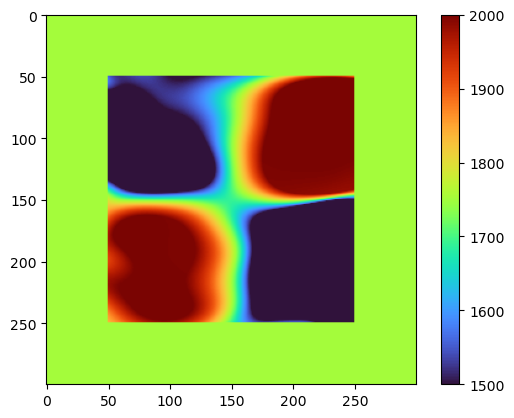

In [8]:
plt.imshow(model.model_params.c, cmap="turbo")
plt.colorbar()

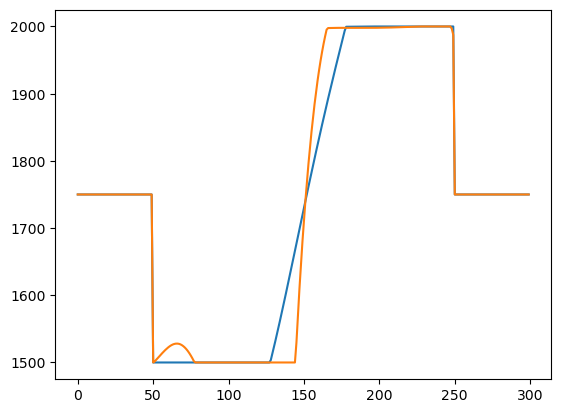

In [9]:
plt.plot(model.model_params.c[100, :])
plt.plot(model.model_params.c[:, 100])

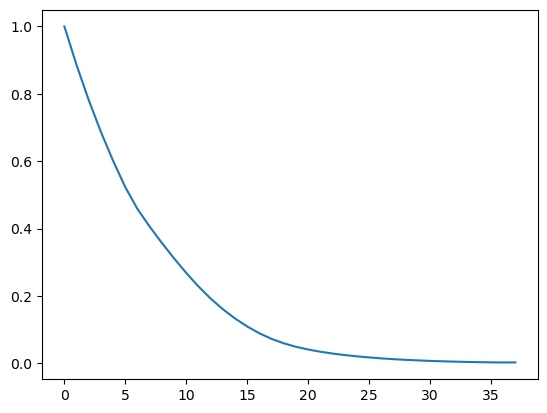

In [10]:
plt.plot(misfits/max(misfits))

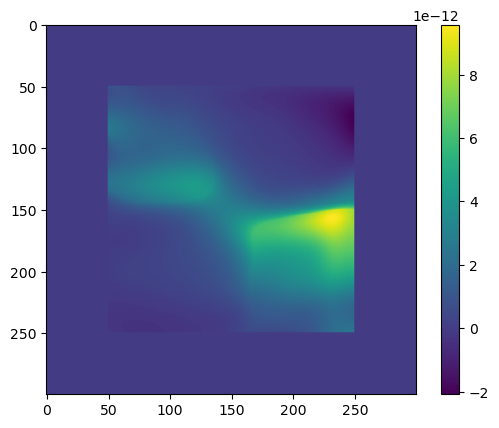

In [11]:
plt.imshow(grad*P/P1)

plt.colorbar()

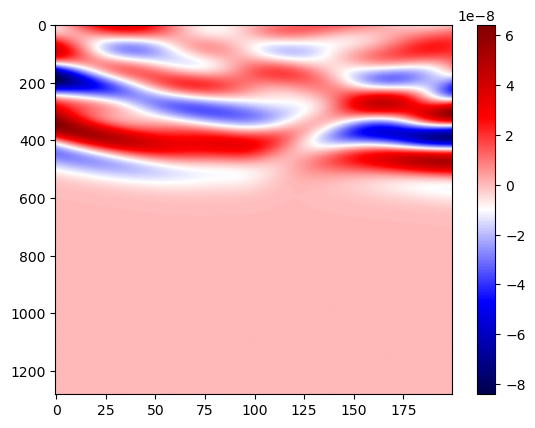

In [12]:
plt.imshow(OUT[-1][2], aspect="auto", cmap="seismic")
plt.colorbar()